In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [99]:
!unzip '/content/drive/MyDrive/Group H.zip'

Archive:  /content/drive/MyDrive/Group H.zip
   creating: Group H/
   creating: Group H/Shen_End/
  inflating: Group H/Shen_End/AHCR_00001_Shen_End_14.jpg  
  inflating: Group H/Shen_End/AHCR_00001_Shen_End_15.jpg  
  inflating: Group H/Shen_End/AHCR_00001_Shen_End_6.jpg  
  inflating: Group H/Shen_End/AHCR_00001_Shen_End_7.jpg  
  inflating: Group H/Shen_End/AHCR_00002_Shen_End_14.jpg  
  inflating: Group H/Shen_End/AHCR_00002_Shen_End_15.jpg  
  inflating: Group H/Shen_End/AHCR_00002_Shen_End_6.jpg  
  inflating: Group H/Shen_End/AHCR_00002_Shen_End_7.jpg  
  inflating: Group H/Shen_End/AHCR_00003_Shen_End_14.jpg  
  inflating: Group H/Shen_End/AHCR_00003_Shen_End_15.jpg  
  inflating: Group H/Shen_End/AHCR_00003_Shen_End_6.jpg  
  inflating: Group H/Shen_End/AHCR_00003_Shen_End_7.jpg  
  inflating: Group H/Shen_End/AHCR_00004_Shen_End_14.jpg  
  inflating: Group H/Shen_End/AHCR_00004_Shen_End_15.jpg  
  inflating: Group H/Shen_End/AHCR_00004_Shen_End_6.jpg  
  inflating: Group H/She

In [100]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

img_width, img_height = 150, 150
data_dir = "/content/Group H"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))  

    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):  
            for img_file in os.listdir(group_path):  
                img_path = os.path.join(group_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(
                        img_path, target_size=(img_width, img_height), color_mode='grayscale'
                    )
                    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except Exception as e:
                    print(f"Error loading image {img_file} in {group_name}: {e}")

    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

if len(images) == 0:
    raise ValueError("No images were loaded. Check the data directory and file paths.")

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(f"Training samples: {x_train.shape[0]}, Testing samples: {x_test.shape[0]}")
print(f"Number of classes: {num_classes}")


Training samples: 2976, Testing samples: 745
Number of classes: 8


In [103]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [104]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [105]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


186/186 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.1406 - loss: 2.1811 - val_accuracy: 0.4698 - val_loss: 1.5084
Epoch 2/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.3862 - loss: 1.6571 - val_accuracy: 0.7248 - val_loss: 0.8067
Epoch 3/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.5828 - loss: 1.1486 - val_accuracy: 0.7463 - val_loss: 0.6874
Epoch 4/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6429 - loss: 1.0110 - val_accuracy: 0.8201 - val_loss: 0.5599
Epoch 5/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6743 - loss: 0.8918 - val_accuracy: 0.8362 - val_loss: 0.4976
Epoch 6/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7142 - loss: 0.7768 - val_accuracy: 0.8550 - val_loss: 0.4256
Epoch 7/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7212 - loss: 0.7953 - val_accuracy: 0.8416 - val_loss: 0.4766
Epoch 8/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.7624 - loss: 0.6926 - val_accuracy: 

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9240 - loss: 0.2555
Train Accuracy: 87.20%
Test Accuracy: 92.48%


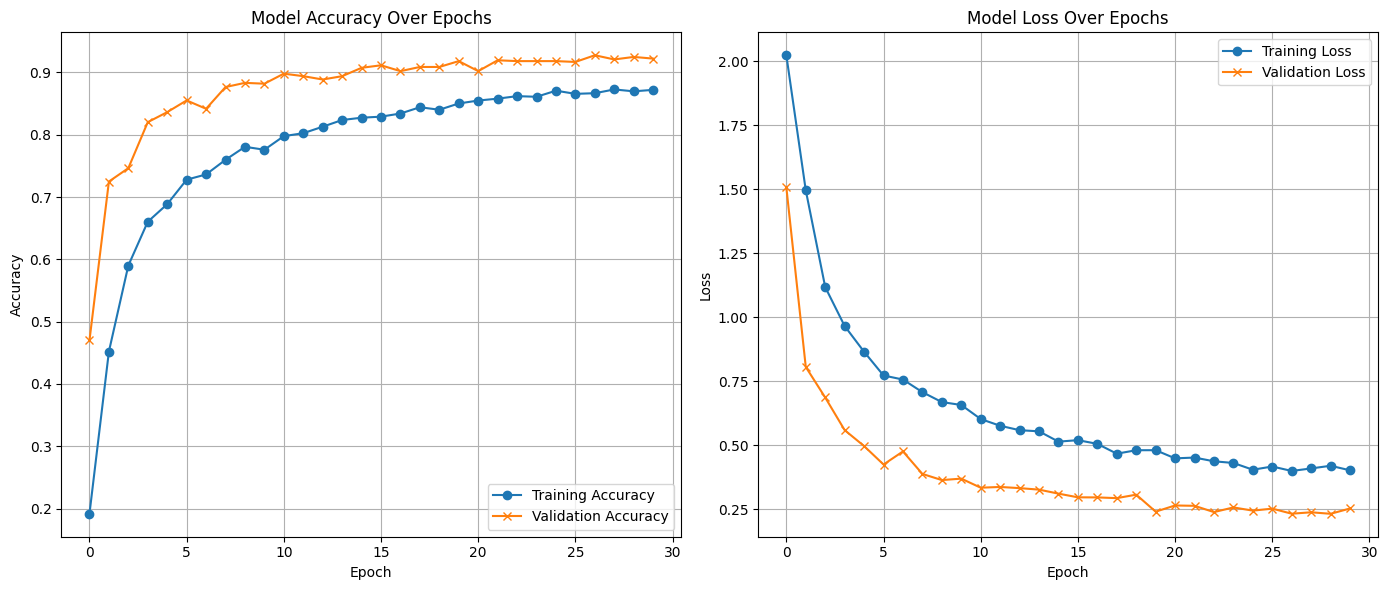

In [106]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


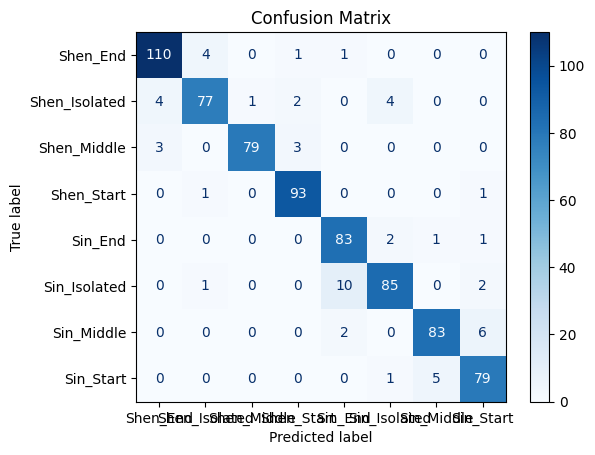

In [108]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


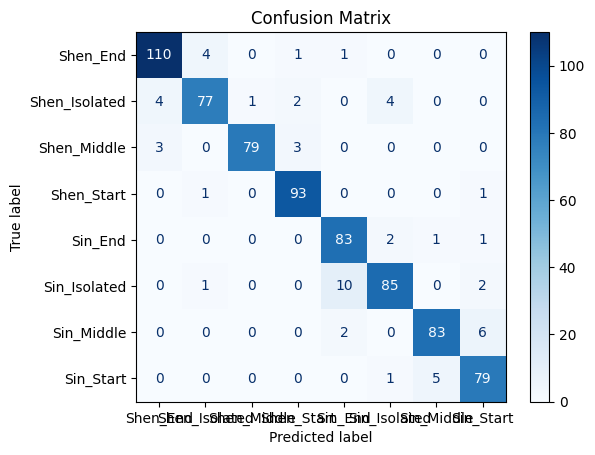

Number of incorrect predictions: 56


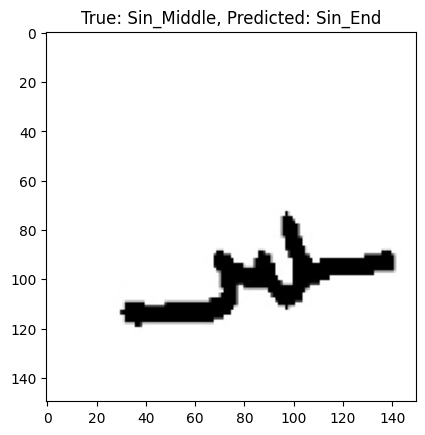

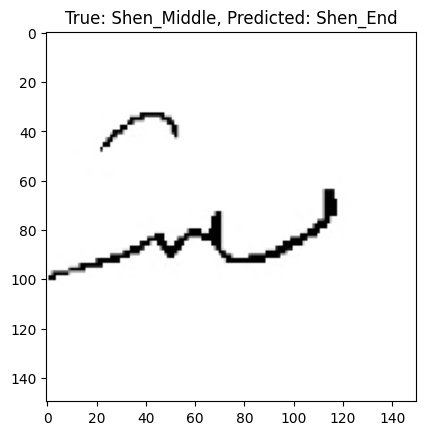

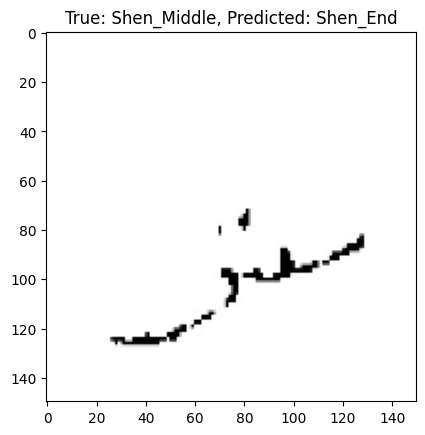

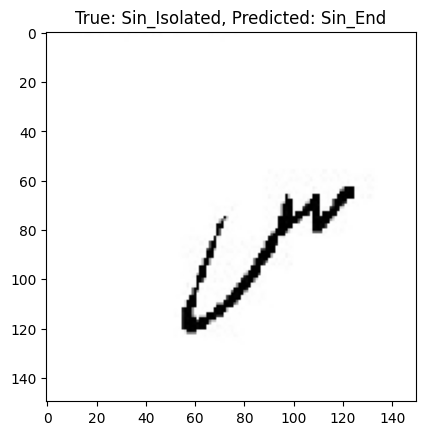

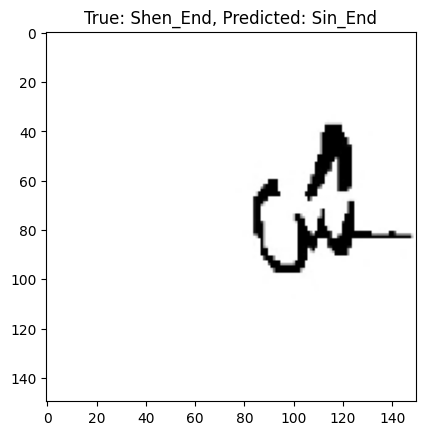

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### decrease dropout and epochs

In [116]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [117]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=25,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/28


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


186/186 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.2085 - loss: 1.9849 - val_accuracy: 0.6564 - val_loss: 0.9218
Epoch 2/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6324 - loss: 1.0654 - val_accuracy: 0.8013 - val_loss: 0.5891
Epoch 3/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.7569 - loss: 0.7412 - val_accuracy: 0.8403 - val_loss: 0.4539
Epoch 4/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.7794 - loss: 0.6682 - val_accuracy: 0.8537 - val_loss: 0.4304
Epoch 5/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8018 - loss: 0.5836 - val_accuracy: 0.8886 - val_loss: 0.3572
Epoch 6/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8208 - loss: 0.5008 - val_accuracy: 0.9007 - val_loss: 0.2908
Epoch 7/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8471 - loss: 0.4832 - val_accuracy: 0.8993 - val_loss: 0.2894
Epoch 8/28
186/186 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8536 - loss: 0.4288 - val_accuracy: 0.

In [113]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9388 - loss: 0.2074
Train Accuracy: 91.16%
Test Accuracy: 93.83%


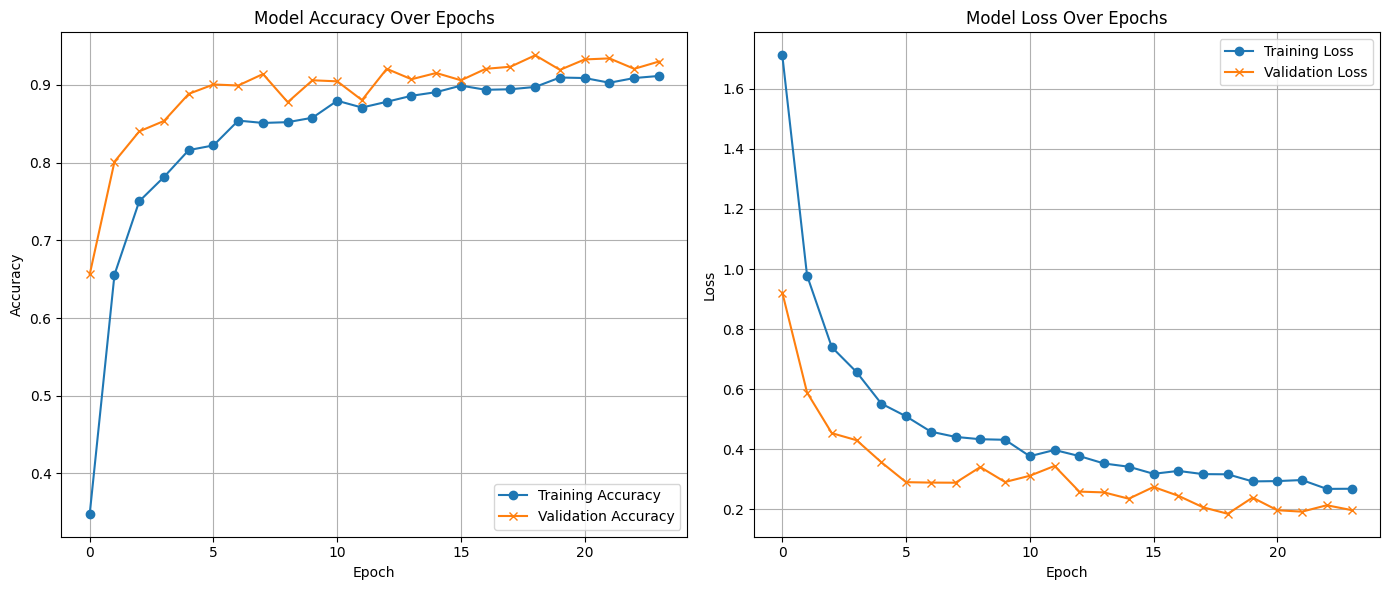

In [114]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


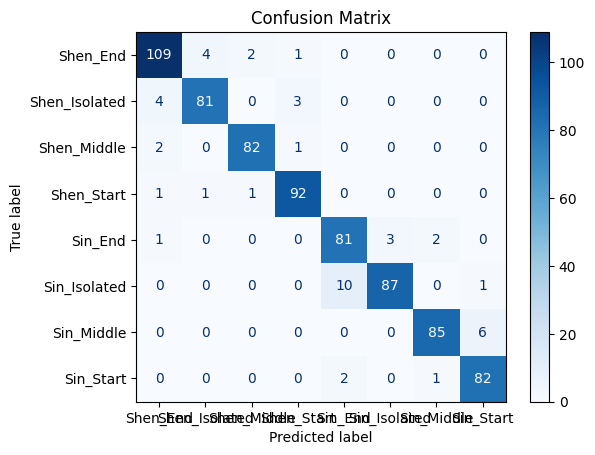

Number of incorrect predictions: 46


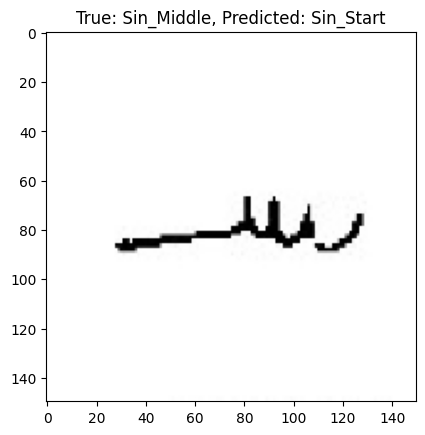

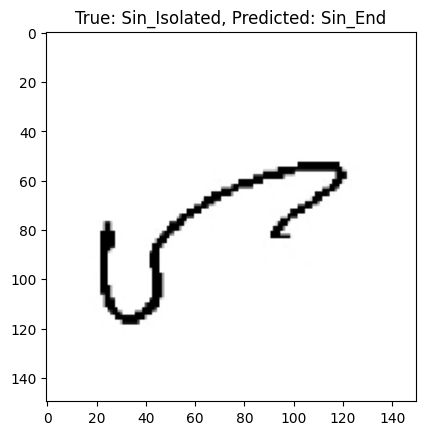

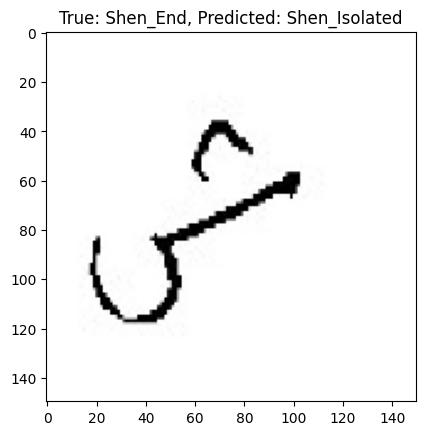

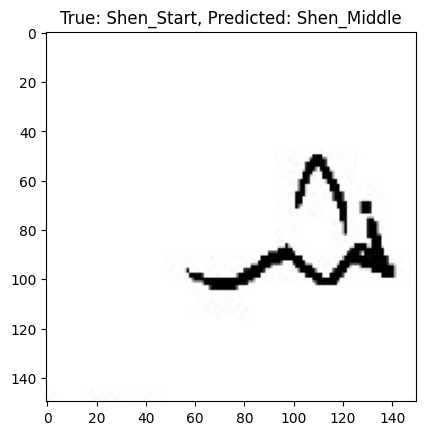

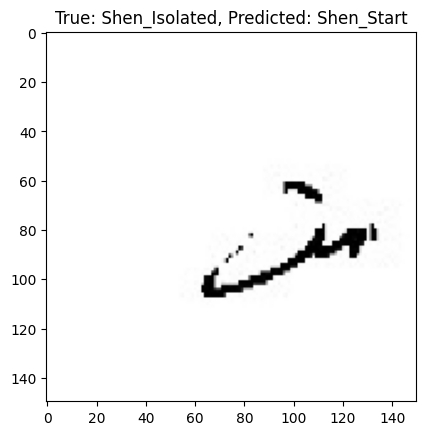

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


### remove dropout and increase epochs

In [143]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [144]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [145]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.1682 - loss: 2.2617 - val_accuracy: 0.5060 - val_loss: 1.2640
Epoch 2/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5649 - loss: 1.2585 - val_accuracy: 0.7718 - val_loss: 0.6488
Epoch 3/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7257 - loss: 0.8009 - val_accuracy: 0.8443 - val_loss: 0.5189
Epoch 4/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7725 - loss: 0.7005 - val_accuracy: 0.8430 - val_loss: 0.4260
Epoch 5/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8034 - loss: 0.6074 - val_accuracy: 0.8711 - val_loss: 0.3686
Epoch 6/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.8443 - loss: 0.4934 - val_accuracy: 0.8899 - val_loss: 0.3498
Epoch 7/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8490 - loss: 0.4489 - val_accuracy: 0.8913 - val_loss: 0.3382
Epoch 8/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8444 - loss: 0.4474 - val_

In [148]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9238 - loss: 0.2322
Train Accuracy: 92.17%
Test Accuracy: 92.62%


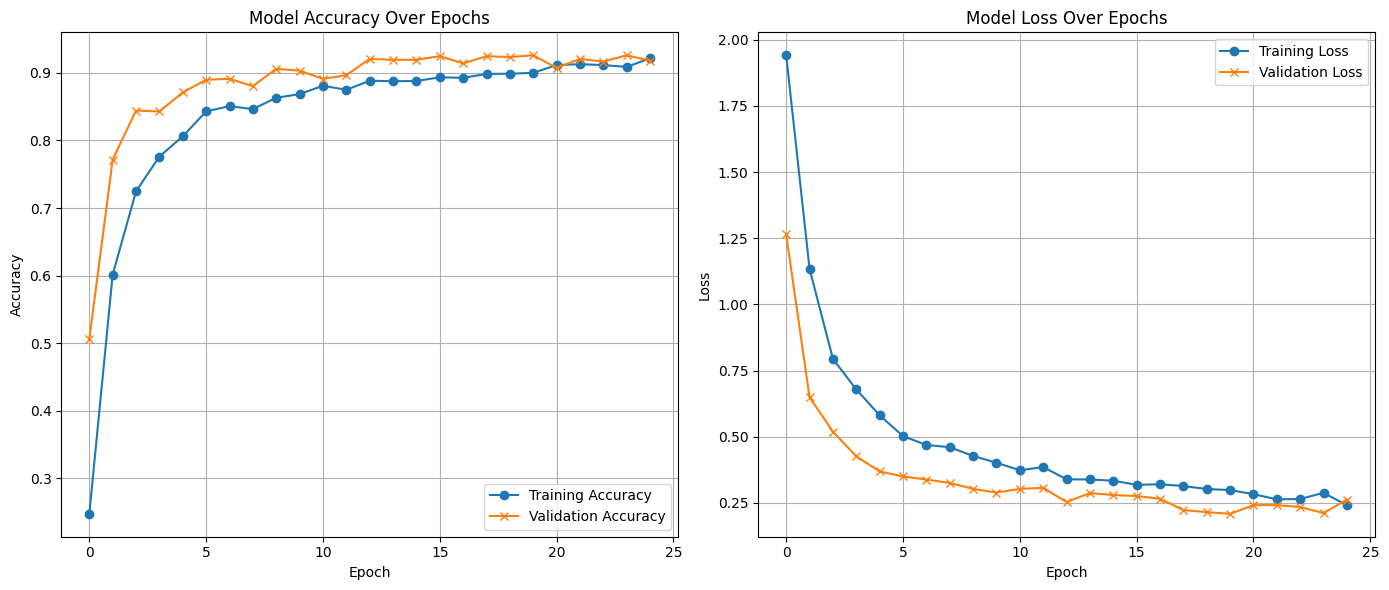

In [149]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


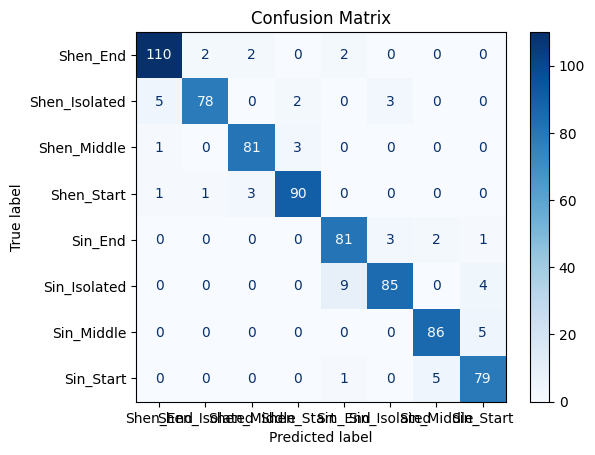

Number of incorrect predictions: 55


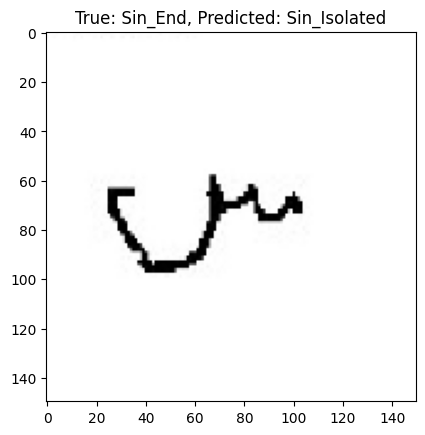

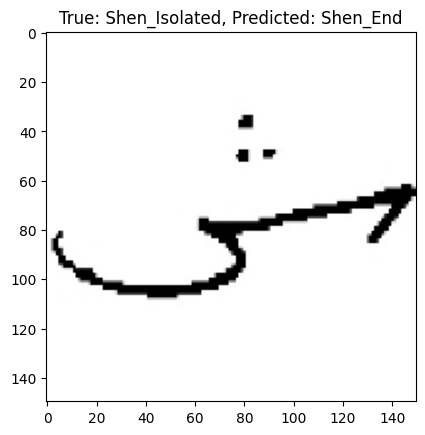

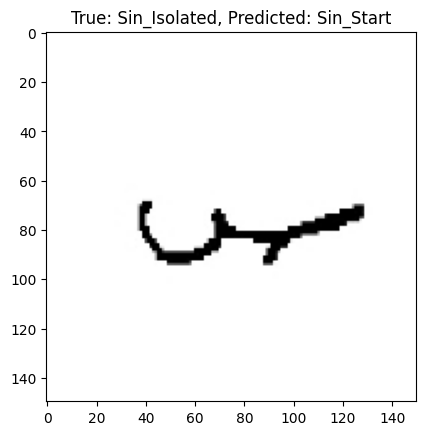

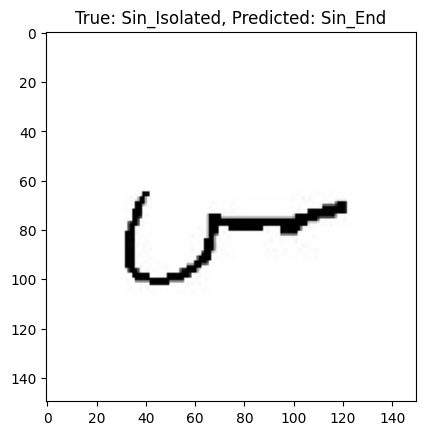

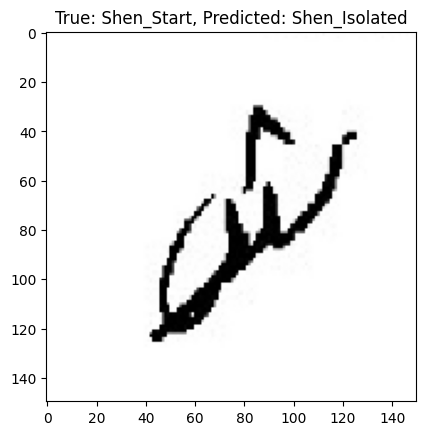

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [151]:
model.save("GrpH.keras")